# plot results of ensemble

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import fiona
import shapely.geometry
from pyproj import Geod
from ewatercycle.observation.grdc import get_grdc_data
from tqdm.notebook import tqdm


from src.paths import *
from src.forcing import generate_lumped_ERA5_forcing,load_lumped_forcing_data
from src.models import simulate_HBV,save_HBV_results
from src.utils import mmday_to_m3s
from src.constants import TYUMEN_ARYK_HBV_PARAMS_CMAES,PARAMETER_NAMES
import src.aral as aral

import glob

import glob
import os

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:

experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "2020-12-31T00:00:00Z"

shapefile_kerki = "Kerki_GRDC"
shapefile_TA = "Tyumen_Aryk_GRDC"
shapefile_Aral = "AralSea"
shapefile_chatly = "Chatly_GRDC"


Syr_kaza = aral.load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = aral.load_grdc_monthly(2817100, name="Amu Darya Chatly")




In [33]:
# -----------------------------
# Tyumen Aryk / Syr Darya
# -----------------------------
output_dir_TA = OUTPUT_HBV / "Tyumen_Aryk_GRDC"
pkl_files_TA_ERA5 = sorted(output_dir_TA.glob("ERA5/Tyumen_Aryk_GRDC_ERA5_1940-2020_cmaes_*.pkl"))
pkl_files_TA_CMIP_HIST = sorted(output_dir_TA.glob("CMIP_HIST/Tyumen_Aryk_GRDC_CMIP_HIST_1940-2014_cmaes_*.pkl"))

rivers_TA_ERA5 = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_TA_ERA5]
rivers_TA_CMIP_HIST = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_TA_CMIP_HIST]

# -----------------------------
# Kerki / Amu Darya
# -----------------------------
output_dir_Kerki = OUTPUT_HBV / "Kerki_GRDC"
pkl_files_Kerki_ERA5 = sorted(output_dir_Kerki.glob("ERA5/Kerki_GRDC_ERA5_1940-2020_cmaes_*.pkl"))
pkl_files_Kerki_CMIP_HIST = sorted(output_dir_Kerki.glob("CMIP_HIST/Kerki_GRDC_CMIP_HIST_1940-2014_cmaes_*.pkl"))

rivers_Kerki_ERA5 = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_Kerki_ERA5]
rivers_Kerki_CMIP_HIST = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_Kerki_CMIP_HIST]

# -----------------------------
# Chatly / Amu Darya
# -----------------------------
output_dir_Chatly = OUTPUT_HBV / "Chatly_GRDC"
pkl_files_Chatly_ERA5 = sorted(output_dir_Chatly.glob("ERA5/Chatly_GRDC_ERA5_1940-2020_cmaes_*.pkl"))
pkl_files_Chatly_CMIP_HIST = sorted(output_dir_Chatly.glob("CMIP_HIST/Chatly_GRDC_CMIP_HIST_1940-2014_cmaes_*.pkl"))

rivers_Chatly_ERA5 = [aral.River.from_pickle(pkl, scaling=1) for pkl in pkl_files_Chatly_ERA5]
rivers_Chatly_CMIP_HIST = [aral.River.from_pickle(pkl, scaling=1) for pkl in pkl_files_Chatly_CMIP_HIST]


In [36]:
from pathlib import Path

def load_rivers(station_name, scaling_era5=1.0, scaling_cmip=1.0):
    """
    Load River objects for a given station, both ERA5 and CMIP_HIST.
    
    Parameters
    ----------
    station_name : str
        Folder name of the station inside OUTPUT_HBV.
    scaling_era5 : float
        Scaling factor for ERA5 pickles.
    scaling_cmip : float
        Scaling factor for CMIP_HIST pickles.
        
    Returns
    -------
    dict
        Dictionary with keys 'ERA5' and 'CMIP_HIST', values are lists of aral.River objects.
    """
    station_dir = OUTPUT_HBV / station_name
    
    # ERA5
    pkl_files_era5 = sorted(station_dir.glob(f"ERA5/{station_name}_ERA5_1940-2020_cmaes_*.pkl"))
    rivers_era5 = [aral.River.from_pickle(pkl, scaling=scaling_era5) for pkl in pkl_files_era5]
    
    # CMIP_HIST
    pkl_files_cmip = sorted(station_dir.glob(f"CMIP_HIST/{station_name}_CMIP_HIST_1940-2014_cmaes_*.pkl"))
    rivers_cmip = [aral.River.from_pickle(pkl, scaling=scaling_cmip) for pkl in pkl_files_cmip]
    
    return {"ERA5": rivers_era5, "CMIP_HIST": rivers_cmip}


In [37]:
rivers_TA = load_rivers("Tyumen_Aryk_GRDC", scaling_era5=0.8, scaling_cmip=0.8)
rivers_Kerki = load_rivers("Kerki_GRDC", scaling_era5=0.8, scaling_cmip=0.8)
rivers_Chatly = load_rivers("Chatly_GRDC", scaling_era5=1.0, scaling_cmip=1.0)

In [39]:
# aral_meteo = xr.open_dataset('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc')

# # Initial settings
# initial_volume = 1100
# ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# n_pairs = min(len(rivers_TA), len(rivers_Chatly))
# ensemble_results = []

# for i in tqdm(range(n_pairs), desc="Running paired Aral simulations"):
#     ta_river = rivers_TA[i]
#     #kerki_river = rivers_Kerki[i]
#     chatly_river = rivers_Chatly[i]

#     # Run the model
#     df_aral = aral.run_connected_aral_model(
#         aral_meteo,
#         rivers=[chatly_river, ta_river],
#         ahv_csv=ahv_file,
#         V0_km3=initial_volume,
#         start_time="1950-01-01",
#         end_time="2020-12-31",
#         tqdm_position = 1,
#     )

#     # Optionally store metadata
#     df_aral.attrs = {
#         "pair_index": i,
#         "Chatly_run": chatly_river.name,
#         "Tyumen_Aryk_run": ta_river.name,
#         "Chatly_parameters": getattr(chatly_river, "metadata", None),
#         "Tyumen_Aryk_parameters": getattr(ta_river, "metadata", None),
#     }

#     ensemble_results.append(df_aral)

In [40]:
from itertools import product

# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Limit to first 10 runs of each type
n_runs = 10
TA_ERA5 = rivers_TA["ERA5"][:n_runs]
TA_CMIP = rivers_TA["CMIP_HIST"][:n_runs]

Chatly_ERA5 = rivers_Chatly["ERA5"][:n_runs]
Chatly_CMIP = rivers_Chatly["CMIP_HIST"][:n_runs]

# Combine all pairs: ERA5-ERA5, CMIP-CMIP (or mix if needed)
ensemble_results = []

# Example: pair ERA5 with ERA5
for i in tqdm(range(n_runs), desc="Running ERA5 paired simulations"):
    ta_river = TA_ERA5[i]
    chatly_river = Chatly_ERA5[i]

    df_aral = aral.run_connected_aral_model(
        aral_meteo,
        rivers=[chatly_river, ta_river],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2020-12-31",
        tqdm_position=1,
    )

    df_aral.attrs = {
        "pair_index": i,
        "Chatly_run": chatly_river.name,
        "Tyumen_Aryk_run": ta_river.name,
        "Chatly_parameters": getattr(chatly_river, "metadata", None),
        "Tyumen_Aryk_parameters": getattr(ta_river, "metadata", None),
        "type": "ERA5"
    }
    ensemble_results.append(df_aral)

# Example: pair CMIP_HIST with CMIP_HIST
for i in tqdm(range(n_runs), desc="Running CMIP_HIST paired simulations"):
    ta_river = TA_CMIP[i]
    chatly_river = Chatly_CMIP[i]

    df_aral = aral.run_connected_aral_model(
        aral_meteo,
        rivers=[chatly_river, ta_river],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2020-12-31",
        tqdm_position=1,
    )

    df_aral.attrs = {
        "pair_index": i,
        "Chatly_run": chatly_river.name,
        "Tyumen_Aryk_run": ta_river.name,
        "Chatly_parameters": getattr(chatly_river, "metadata", None),
        "Tyumen_Aryk_parameters": getattr(ta_river, "metadata", None),
        "type": "CMIP_HIST"
    }
    ensemble_results.append(df_aral)


Running ERA5 paired simulations:   0%|          | 0/10 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

...

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

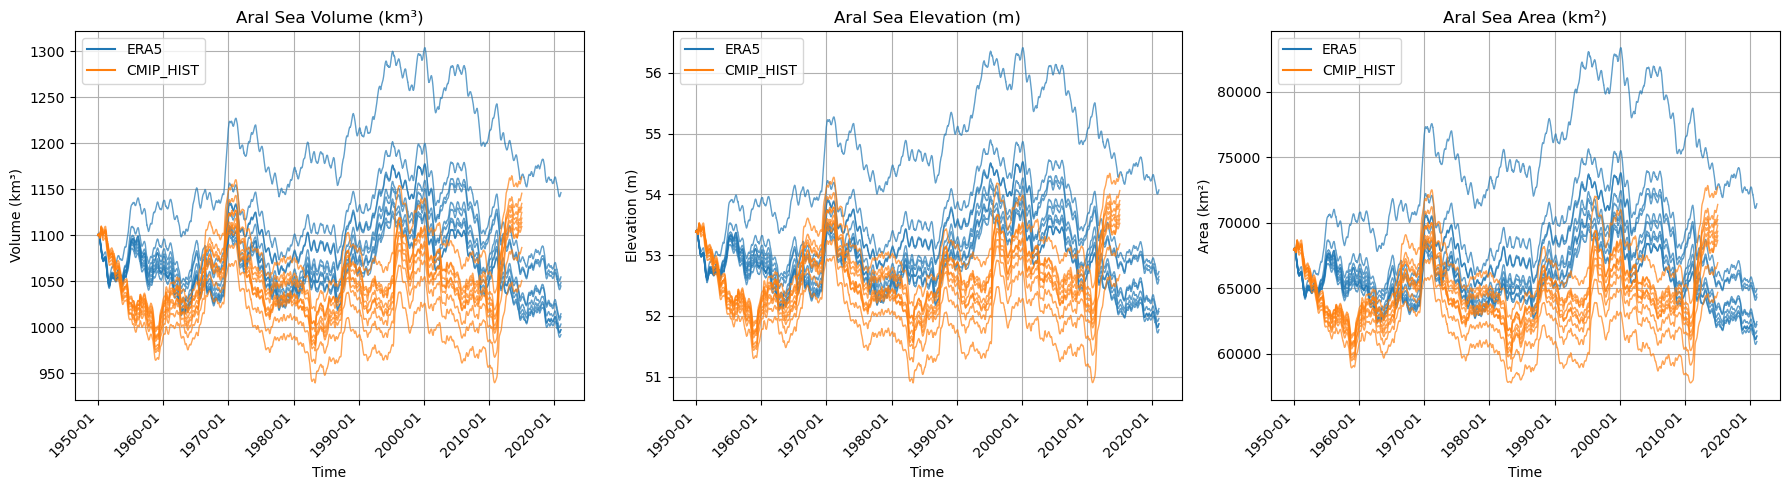

In [44]:
# Separate ERA5 and CMIP_HIST
n_runs = 10
ensemble_ERA5 = ensemble_results[:n_runs]      # first 10 ERA5
ensemble_CMIP = ensemble_results[n_runs:2*n_runs]  # next 10 CMIP_HIST

# Define group labels
groups = ["ERA5"] * len(ensemble_ERA5) + ["CMIP_HIST"] * len(ensemble_CMIP)

# Combine lists in same order as groups
ensemble_to_plot = ensemble_ERA5 + ensemble_CMIP

# Plot
aral.plot_aral_ensemble_results(
    ensemble_to_plot,
    groups=groups,
    # figsize=(10, 4),
    # title="Aral Sea Volume Ensemble (ERA5 vs CMIP_HIST)",
    # xlabel="Year",
    # ylabel="Volume (km³)",
    # legend=True,
    # alpha=0.6,   # transparency for overlapping lines
)


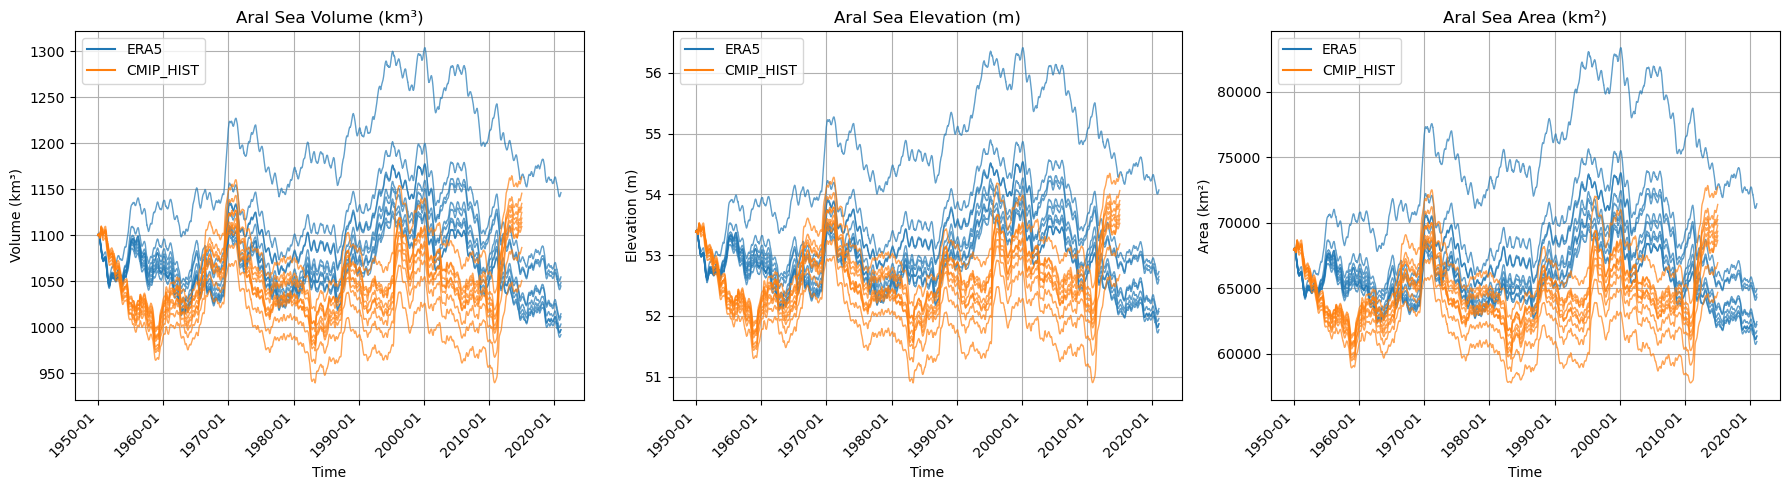

In [45]:


aral.plot_aral_ensemble_results(ensemble_results, groups=groups)

In [47]:
# rivers_Chatly[0].plot_yearly()
# rivers_TA[0].plot_yearly()

In [48]:
import pandas as pd
import xarray as xr
from pathlib import Path
import glob
import os

def make_obs(csv_file: Path, nc_folder: Path):
    """
    Load historical CSV and DAHITI NetCDF water level observations
    and return a list of tuples (DataFrame, label).

    Parameters
    ----------
    csv_file : Path
        Path to historical elevation CSV file
    nc_folder : Path
        Base folder where DAHITI NetCDF files are stored

    Returns
    -------
    obs_list : list of tuples
        Each tuple is (df, label), where df has columns ['time', 'elevation_m']
    """
    obs_list = []


    # ---------- CSV (historical table) ----------
    if csv_file.exists():
        df_csv = pd.read_csv(csv_file, sep=';', decimal=',')

        if not {'Year', 'elevation'}.issubset(df_csv.columns):
            raise ValueError(
                f"CSV must contain columns 'Year' and 'elevation'. Found: {df_csv.columns}"
            )

        df_csv = df_csv[['Year', 'elevation']].copy()
        df_csv['time'] = pd.to_datetime(df_csv['Year'], format='%Y')
        df_csv['elevation_m'] = df_csv['elevation'].astype(float)

        obs_list.append(
            (df_csv[['time', 'elevation_m']], 'Historical')
        )
    else:
        print(f"CSV file not found: {csv_file}")

    # --- Load all DAHITI NetCDF files ---
    nc_files = glob.glob(os.path.join(nc_folder, "**", "*.nc"), recursive=True)
    print(f"Found {len(nc_files)} NetCDF files in {nc_folder}")

    for nc_file in nc_files:
        ds = xr.open_dataset(nc_file)
        df_nc = pd.DataFrame({
            "time": pd.to_datetime(ds['datetime'].values),
            "elevation_m": ds['water_level'].values
        })
        obs_list.append((df_nc, 'Historical'))

    return obs_list


In [49]:
csv_file = BATHYMETRY / "Nachtnebel_table.csv"
nc_folder = DAHITI

observations = make_obs(csv_file, nc_folder)


Found 4 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


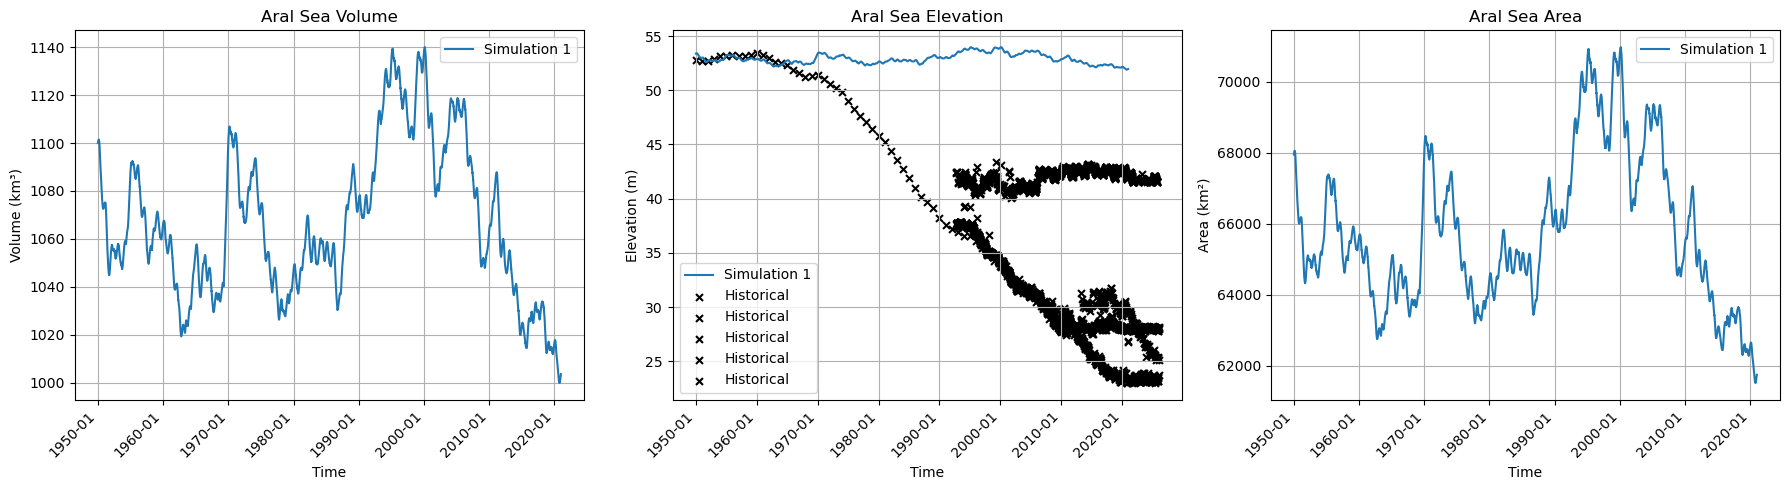

In [50]:
aral.plot_aral_results([ensemble_results[0]], observations=observations)

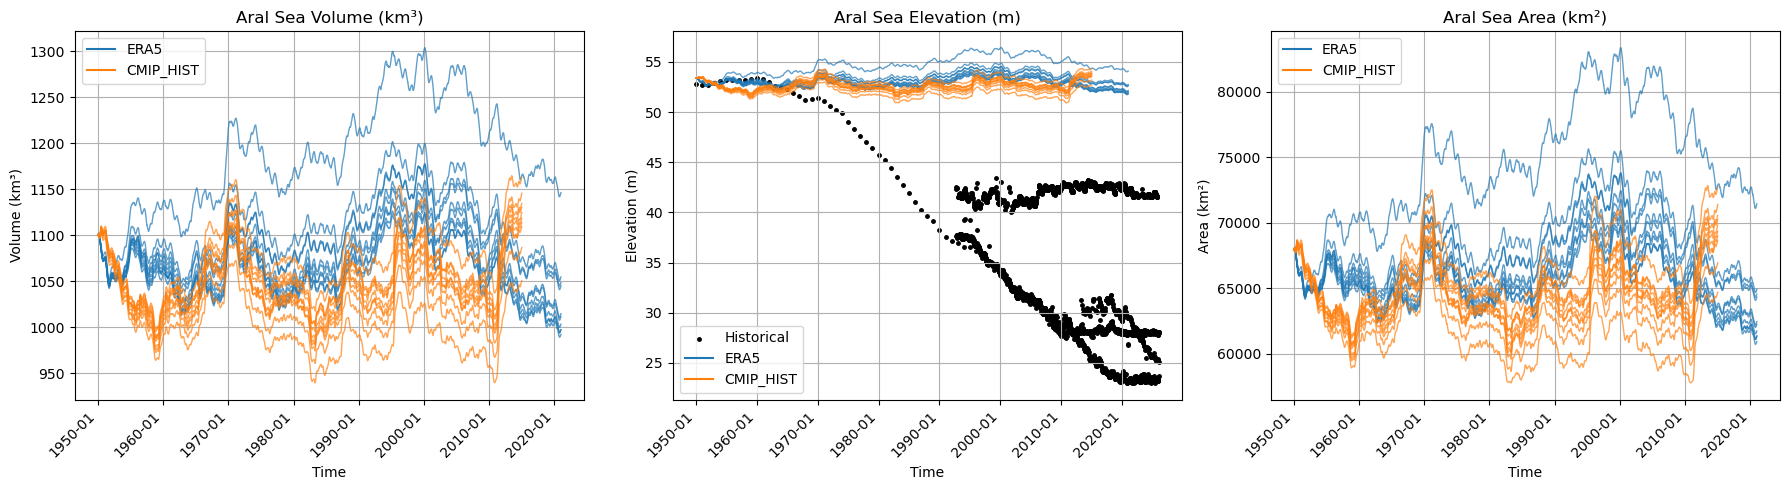

In [53]:
aral.plot_aral_ensemble_results(ensemble_results, groups=groups,observations=observations)

In [22]:
ensemble_results[0]



,time,volume_km3,area_km2,elevation_m,Q_in_km3day,evap_km3day
0,1950-01-01 12:00:00,1100.000000,NaN,NaN,NaN,NaN
1,1950-01-02 12:00:00,1100.054000,67947.027027,53.384095,0.080290,0.026289
2,1950-01-03 12:00:00,1100.108246,67951.113541,53.384897,0.079508,0.025262
3,1950-01-04 12:00:00,1100.154231,67955.218647,53.385704,0.078736,0.032752
4,1950-01-05 12:00:00,1100.186705,67958.698581,53.386387,0.077974,0.045500
...,...,...,...,...,...,...
25927,2020-12-26 12:00:00,1003.415532,61731.874059,51.956290,0.073423,0.025961
25928,2020-12-27 12:00:00,1003.458802,61734.887145,51.956976,0.072748,0.029477
25929,2020-12-28 12:00:00,1003.505707,61737.634130,51.957602,0.072081,0.025176
25930,2020-12-29 12:00:00,1003.544968,61740.611788,51.958280,0.071421,0.032160


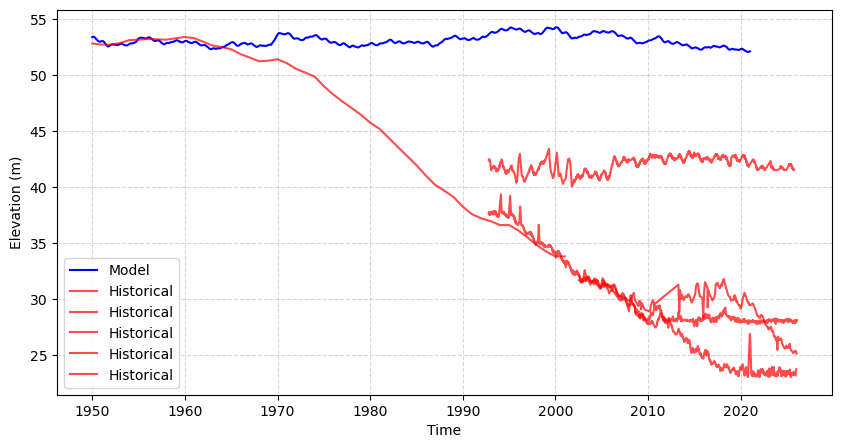

In [23]:
plt.figure(figsize=(10,5))
n=2

# Plot first ensemble member
plt.plot(ensemble_results[n]["time"], ensemble_results[n]["elevation_m"], label='Model', color='blue')

# Plot all observations
for obs in observations:
    df, label = obs  # unpack the tuple
    plt.plot(df['time'], df['elevation_m'], label=label, color='red', alpha=0.7)\

plt.xlabel("Time")
plt.ylabel("Elevation (m)")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()
